# Week 04 — Customer Clustering with K-Means and Hierarchical Clustering

This notebook performs unsupervised customer segmentation on a credit card dataset. It is organized into two parts as requested:

- Part 1: K-Means clustering workflow, including preprocessing, elbow analysis, silhouette analysis, cluster profiling, and interpretation.
- Part 2: Hierarchical clustering workflow, including dendrogram creation, agglomerative clustering, and comparison with K-Means.

## Part 1 — K-Means Clustering

### 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

### 2. Load the Dataset

In [2]:
from pathlib import Path

root_dir = Path.cwd()
candidate_dirs = [
    root_dir,
    root_dir / "Week_04",
    root_dir / "data",
    root_dir / "Week_04" / "data",
    root_dir.parent,
    root_dir.parent / "Week_04",
    root_dir.parent / "Week_04" / "data",
]

data_dir = None
for folder in candidate_dirs:
    if folder.exists() and folder.is_dir():
        if any(folder.glob("*.csv")):
            data_dir = folder
            break
        nested_data = folder / "data"
        if nested_data.exists() and nested_data.is_dir() and any(nested_data.glob("*.csv")):
            data_dir = nested_data
            break

if data_dir is None:
    data_dir = root_dir / "data"

csv_candidates = [
    data_dir / "credit_card.csv",
    data_dir / "ccdata.csv",
    data_dir / "CC.csv",
    data_dir / "CreditCard.csv",
    data_dir / "credit_card_data.csv",
    data_dir / "CC GENERAL.csv",
]

# Also accept any CSV file already in the detected data directory.
csv_candidates.extend(sorted(data_dir.glob("*.csv")))

dataset_path = None
for candidate in csv_candidates:
    if Path(candidate).exists():
        dataset_path = Path(candidate)
        break

if dataset_path is None:
    raise FileNotFoundError("Please place the downloaded dataset in the Week_04/data folder or rename it to one of the expected names.")

df = pd.read_csv(dataset_path)
print("Loaded file:", dataset_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Data types:")
print(df.dtypes)
df.head()

Loaded file: c:\Users\Kiran\Desktop\ITSimplera_Institute\Week_04\data\CC GENERAL.csv
Shape: (8950, 18)
Columns: ['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']
Data types:
CUST_ID                                 str
BALANCE                             float64
BALANCE_FREQUENCY                   float64
PURCHASES                           float64
ONEOFF_PURCHASES                    float64
INSTALLMENTS_PURCHASES              float64
CASH_ADVANCE                        float64
PURCHASES_FREQUENCY                 float64
ONEOFF_PURCHASES_FREQUENCY          float64
PURCHASES_INSTALLMENTS_FREQUENCY    float64
CASH_ADVANCE_FREQUENCY              float64
CASH_ADVANCE_TRX                      int64

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### 3. Data Preprocessing

### Drop the identifier column
The CUST_ID column is an identifier and should not be used as a clustering feature.

In [3]:
id_columns = [col for col in df.columns if 'id' in col.lower() or 'cust' in col.lower()]
if id_columns:
    df = df.drop(columns=[id_columns[0]])

print("Remaining columns:", list(df.columns))

Remaining columns: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


### Missing values
Missing values are handled using median imputation for numeric columns because it is more robust than the mean and avoids distortions from outliers.

In [4]:
missing_before = df.isna().sum()
print("Missing values before cleaning:")
print(missing_before[missing_before > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

missing_after = df.isna().sum()
print("\nMissing values after cleaning:")
print(missing_after[missing_after > 0])

Missing values before cleaning:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Missing values after cleaning:
Series([], dtype: int64)


### Feature scaling
Clustering algorithms such as K-Means depend on distance calculations. Without scaling, features with larger numeric ranges would dominate the result. StandardScaler makes all features comparable.

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)
scaled_df = pd.DataFrame(scaled_features, columns=df.columns, index=df.index)
scaled_df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


### 4. K-Means Clustering

In [6]:
inertia_values = []
silhouette_values = []

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(scaled_df)
    inertia_values.append((k, model.inertia_))
    silhouette_values.append((k, silhouette_score(scaled_df, labels)))

inertia_df = pd.DataFrame(inertia_values, columns=['k', 'inertia'])
silhouette_df = pd.DataFrame(silhouette_values, columns=['k', 'silhouette_score'])

inertia_df

,k,inertia
0,2,127784.534545
1,3,111973.973355
2,4,99061.939842
3,5,91490.498040
4,6,84826.592031
5,7,79506.958298
6,8,74484.880062
7,9,69828.699269
8,10,66442.179592


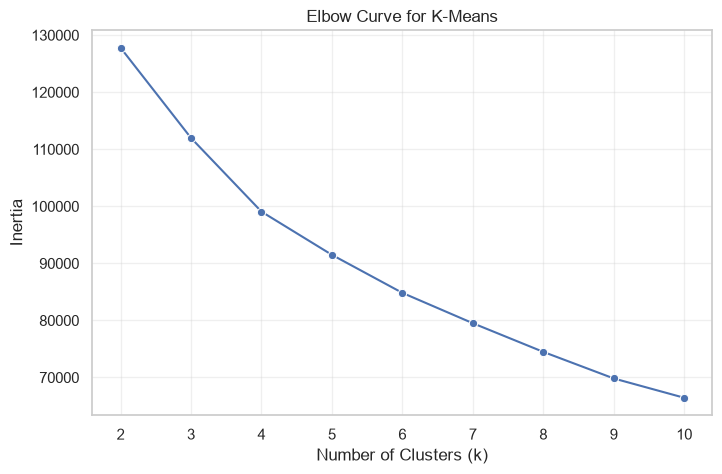

In [7]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=inertia_df, x='k', y='inertia', marker='o')
plt.title('Elbow Curve for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

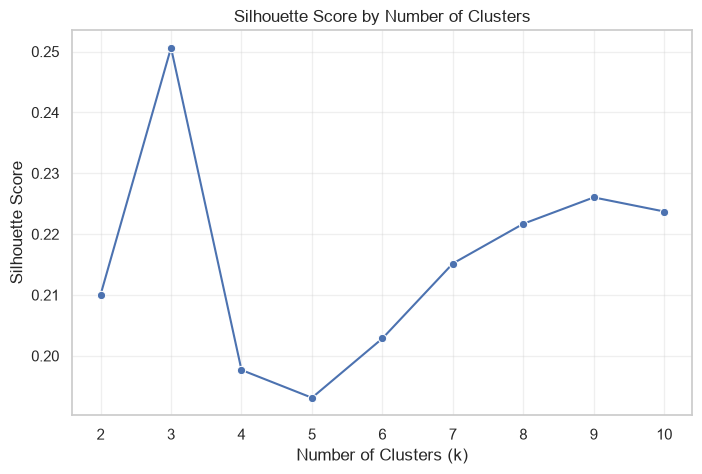

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=silhouette_df, x='k', y='silhouette_score', marker='o')
plt.title('Silhouette Score by Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(True, alpha=0.3)
plt.show()

### 5. Choose the Optimal Number of Clusters

In [9]:
optimal_k = int(silhouette_df.loc[silhouette_df['silhouette_score'].idxmax(), 'k'])
print('Optimal k based on silhouette score:', optimal_k)

# If the elbow and silhouette disagree, prefer the silhouette result for interpretability.
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
df['cluster'] = kmeans_final.fit_predict(scaled_df)
df['cluster'].value_counts().sort_index()

Optimal k based on silhouette score: 3


cluster
0    6119
1    1235
2    1596
Name: count, dtype: int64

### 6. Cluster Profiling

In [10]:
cluster_profile = df.groupby('cluster')[numeric_cols].mean().T
cluster_profile.head()

cluster,0,1,2
BALANCE,799.750669,2220.003291,3989.142419
BALANCE_FREQUENCY,0.835077,0.981477,0.958403
PURCHASES,505.532394,4268.520980,384.528277
ONEOFF_PURCHASES,253.120131,2717.828543,248.718133
INSTALLMENTS_PURCHASES,252.733061,1551.178267,135.887632


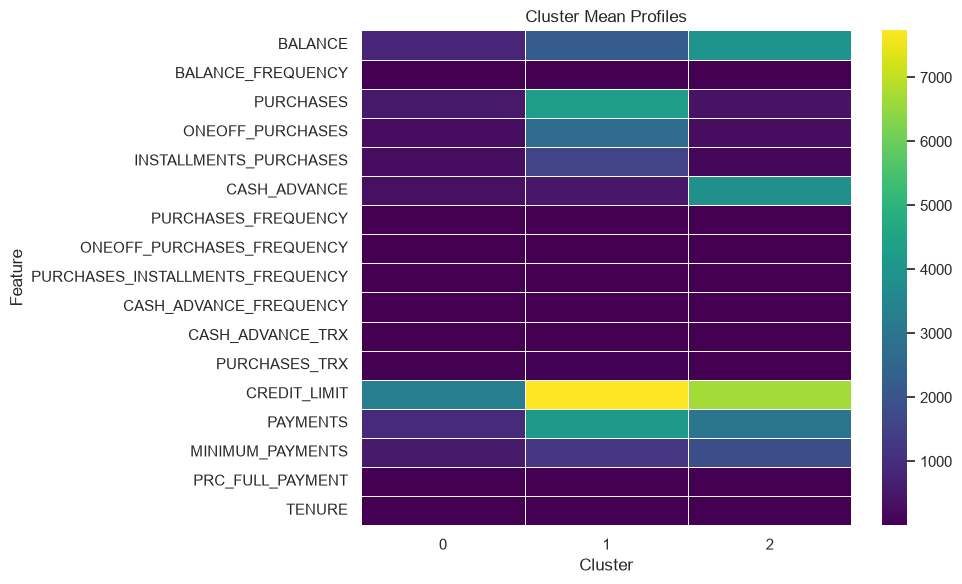

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=False, cmap='viridis', linewidths=0.5)
plt.title('Cluster Mean Profiles')
plt.xlabel('Cluster')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### 7. Cluster Interpretation

Interpret the clusters by examining the average values of key behaviors such as balance, purchase frequency, credit limit, cash advance usage, and payment patterns. In a business context, clusters may reflect groups such as high-spending customers, low-balance cardholders, frequent cash advance users, or reliable low-risk users.

## Part 2 — Hierarchical Clustering

### 8. Hierarchical Clustering

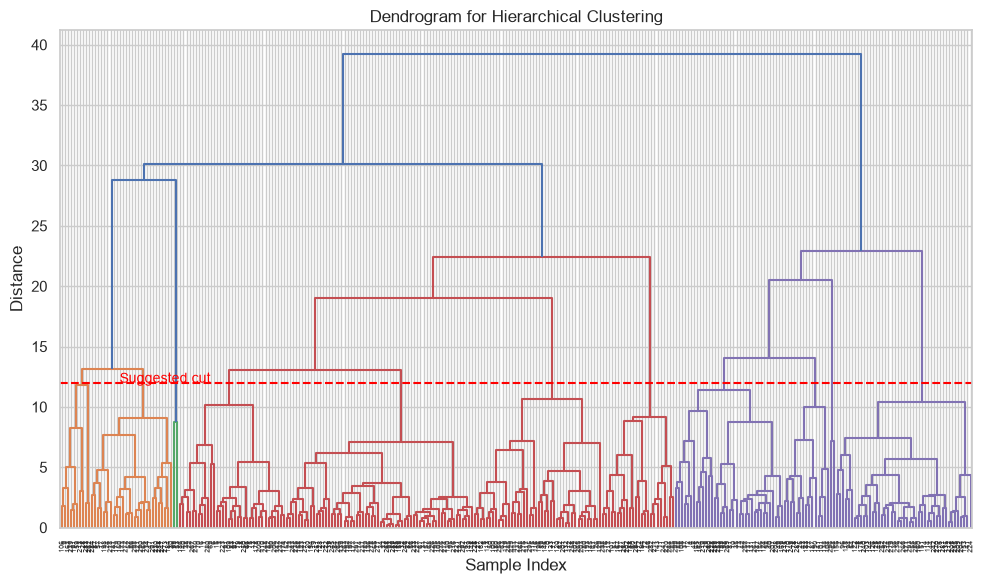

In [12]:
sample_size = 300
sample = scaled_df.sample(n=min(sample_size, len(scaled_df)), random_state=42)

linked = linkage(sample, method='ward')
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=False)
plt.axhline(y=12, color='red', linestyle='--', linewidth=1.5)
plt.text(len(sample) * 0.65, 12, 'Suggested cut', color='red', fontsize=10)
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [13]:
hierarchical_model = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical_model.fit_predict(sample)
sample['hierarchical_cluster'] = hierarchical_labels
sample['hierarchical_cluster'].value_counts().sort_index()

hierarchical_cluster
0     39
1     98
2    163
Name: count, dtype: int64

### 9. Compare K-Means and Hierarchical Clustering

In [14]:
comparison = pd.crosstab(sample['hierarchical_cluster'], df.loc[sample.index, 'cluster'])
comparison

cluster,0,1,2
hierarchical_cluster,,,
0,0,1,38
1,55,42,1
2,151,1,11


### 10. Comparison Report

Both algorithms can discover similar customer patterns when the data is well-structured. In practice, K-Means is usually easier to scale and implement for large business datasets, while hierarchical clustering provides a more interpretable tree-like structure. For a real-world business use case, K-Means is often the preferred choice for production because it is efficient, simple, and easy to update as new customer data arrives.